# Product Shopping Agent — One Self-Contained Agent Skill

This notebook solves the same shopping task as Notebook 2, but the agent receives one directory-backed capability: `product-shopping`. The directory contains both the procedure and the executable product client.

> **Tracing notice:** automatic instrumentation sends prompts, model activity, skill arguments, and script results to the configured Arize Phoenix project. Use only the supplied product examples and classroom prompts.

## Goal

By the end, you can explain:

1. how an Agent Skill packages instructions and supporting resources;
2. how ADK discovers and loads `SKILL.md` only when relevant;
3. why a host needs an explicit executor for bundled scripts; and
4. how the skill trajectory differs from direct function tools in Phoenix.

```text
User → ADK agent → load product-shopping
                 → run bundled search operation
                 → run bundled details operation
                 → grounded comparison
```

## Setup

### 1. Install the libraries

Run this once for the current kernel. The version range keeps this lesson on the Google ADK 2.x Agent Skills API used by the examples.

If Jupyter asks for a kernel restart, restart it and continue with the participant setup cell.

In [1]:
%pip install -q "google-adk[extensions]>=2.5.0,<3" "arize-phoenix-otel>=0.16.0" \
    openinference-instrumentation-google-adk \
    openinference-instrumentation-google-genai \
    google-genai httpx python-dotenv nbformat

Note: you may need to restart the kernel to use updated packages.


### 2. Create the environment file

Replace the placeholder values below, then run the cell. The `.env` file is ignored by Git, so credentials stay out of the notebook itself.

Use your name or another unique value for `PHOENIX_PROJECT_NAME` so your traces are easy to find.

In [2]:
%%writefile .env
GOOGLE_API_KEY=your-google-api-key
PHOENIX_API_KEY=your-phoenix-api-key
PHOENIX_PROJECT_NAME=your-name
PHOENIX_COLLECTOR_ENDPOINT=https://app.phoenix.arize.com/s/adk-demo-search

Overwriting .env


### 3. Set the notebook values

The notebook uses the credentials from the wiki cell and works when started from either the repository root or `notebooks/`.

In [3]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()


REPOSITORY_ROOT = Path.cwd().resolve()
if REPOSITORY_ROOT.name == "notebooks":
    REPOSITORY_ROOT = REPOSITORY_ROOT.parent

PROJECT_NAME = os.environ["PHOENIX_PROJECT_NAME"]
GOOGLE_MODEL = os.getenv("GOOGLE_MODEL", "gemini-3.1-flash-lite")
print(f"Using {GOOGLE_MODEL} with Phoenix project {PROJECT_NAME!r}.")

Using gemini-3.1-flash-lite with Phoenix project 'product-notebook-saved-output-20260721'.


### 4. Enable Phoenix tracing

A **span** records one operation, such as a model request or tool execution. Related spans form a **trace**. The instrumentors below automatically connect Google GenAI and Google ADK operations to Phoenix.

Run this cell once per kernel. The guard prevents duplicate instrumentation when a cell is rerun.

In [4]:
from openinference.instrumentation.google_adk import GoogleADKInstrumentor
from openinference.instrumentation.google_genai import GoogleGenAIInstrumentor
from phoenix.otel import register

os.environ["PHOENIX_PROJECT_NAME"] = PROJECT_NAME
os.environ.setdefault(
    "PHOENIX_COLLECTOR_ENDPOINT",
    "https://app.phoenix.arize.com/s/adk-demo-search",
)
os.environ.setdefault("GOOGLE_GENAI_USE_VERTEXAI", "FALSE")

if "_PHOENIX_TRACER_PROVIDER" not in globals():
    _PHOENIX_TRACER_PROVIDER = register(
        project_name=PROJECT_NAME,
        batch=True,
    )
    GoogleGenAIInstrumentor().instrument(
        tracer_provider=_PHOENIX_TRACER_PROVIDER
    )
    GoogleADKInstrumentor().instrument(
        tracer_provider=_PHOENIX_TRACER_PROVIDER
    )

tracer_provider = _PHOENIX_TRACER_PROVIDER
print(f"Phoenix tracing enabled for project={PROJECT_NAME!r}.")

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: product-notebook-saved-output-20260721
|  Span Processor: BatchSpanProcessor
|  Collector Endpoint: https://app.phoenix.arize.com/s/adk-demo-search/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {'authorization': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



/home/npatta01/anaconda3/lib/python3.13/site-packages/phoenix/otel/otel.py:520: UserWarning: Could not infer collector endpoint protocol, defaulting to HTTP.
  warnings.warn("Could not infer collector endpoint protocol, defaulting to HTTP.")


Phoenix tracing enabled for project='product-notebook-saved-output-20260721'.


## Steps

### Step 1 — inspect the skill as a directory

A **skill** is a directory containing a required `SKILL.md` plus optional references, assets, and scripts. Its short description supports discovery; its full instructions load only when the skill is relevant.

This skill has one cohesive CLI with two operations rather than two separately registered agent tools.

In [5]:
SKILL_DIR = REPOSITORY_ROOT / "skills" / "product-shopping"
SKILL_MD = SKILL_DIR / "SKILL.md"
SKILL_SCRIPT = SKILL_DIR / "scripts" / "product_catalog.py"

print("product-shopping/")
print("├── SKILL.md")
print("└── scripts/")
print("    └── product_catalog.py")

product-shopping/
├── SKILL.md
└── scripts/
    └── product_catalog.py


### Step 2 — read the procedure the model will load

`SKILL.md` explains when the skill applies, the exact script interface, the search-then-details sequence, and the grounding rules. Displaying it makes the agent's operating procedure inspectable rather than hidden in framework code.

In [6]:
from IPython.display import Markdown, display

display(Markdown(SKILL_MD.read_text(encoding="utf-8")))

---
name: product-shopping
description: Use for finding products, inspecting full product details, and making grounded product comparisons.
---

# Product shopping

Use this skill whenever a user asks you to find, inspect, compare, or recommend products.

The bundled script is `scripts/product_catalog.py`. Use `run_skill_script` with `args` as a complete list of command-line arguments.

## Available operations

Search for candidates:

```text
run_skill_script(
  skill_name="product-shopping",
  file_path="scripts/product_catalog.py",
  args=["search", "--query", "55-inch 4K TV under $400"]
)
```

Retrieve authoritative details for one product ID returned by search:

```text
run_skill_script(
  skill_name="product-shopping",
  file_path="scripts/product_catalog.py",
  args=["details", "--product-id", "123456789"]
)
```

## Procedure

1. Search before making a recommendation. Include the user's meaningful constraints in one concise query.
2. Use only returned search rows when selecting candidates. Discard rows that clearly violate requested constraints such as product type, screen size, or budget. For “highly rated,” consider both rating and review count.
3. When the user asks to compare full details, run `details` separately for every selected product ID.
4. Compare only fields present in the returned records. Clearly identify missing availability, seller, brand, or specification data.
5. Recommend one product only after retrieving the necessary detail records, and explain the evidence behind the choice.

## Grounding and errors

- Never invent a product, product ID, price, rating, availability, seller, brand, or specification.
- Never treat search snippets as complete product details.
- If search returns fewer candidates than requested, say how many were found.
- If the script returns an error, report it plainly and stop rather than guessing another product ID or script path.


### Step 3 — load the skill and choose its executor

`load_skill_from_dir` reads `SKILL.md` and bundles the files under `scripts/`. `SkillToolset` exposes discovery, loading, resource access, and script execution to the agent.

> **Trusted-code boundary:** this lesson uses `UnsafeLocalCodeExecutor` only because `product_catalog.py` is a trusted, instructor-authored file committed with the notebook. Never use this executor for unknown or user-supplied skills. Production systems should use a container or managed sandbox.

In [7]:
from google.adk.code_executors import UnsafeLocalCodeExecutor
from google.adk.skills import load_skill_from_dir
from google.adk.tools.skill_toolset import SkillToolset

product_shopping_skill = load_skill_from_dir(SKILL_DIR)
trusted_local_executor = UnsafeLocalCodeExecutor(timeout_seconds=45)
product_shopping_toolset = SkillToolset(
    skills=[product_shopping_skill],
    code_executor=trusted_local_executor,
    script_timeout=40,
)

print("Loaded skill:", product_shopping_skill.name)
print("Bundled scripts:", product_shopping_skill.resources.list_scripts())

Loaded skill: product-shopping
Bundled scripts: ['product_catalog.py']


### Step 4 — give the agent the skill toolset

The agent receives the skill toolset instead of separately registered product functions. The instruction stays concise so you can observe how the skill guides the agent.

In [8]:
from google.adk.agents import Agent
from google.adk.runners import InMemoryRunner

SYSTEM_INSTRUCTION = (
    "You are a helpful shopping assistant. "
    "Use the available skill when needed and base your answer on its results."
)

shopping_agent = Agent(
    name="product_skill_agent",
    model=GOOGLE_MODEL,
    instruction=SYSTEM_INSTRUCTION,
    tools=[product_shopping_toolset],
)
skill_runner = InMemoryRunner(
    agent=shopping_agent,
    app_name="product_agent_skill_phoenix",
)
print("Skill-based agent ready.")

Skill-based agent ready.


### Run turn 1 — discover two candidates

A **session** is the conversation record ADK carries across turns. The first request should search for candidates and preserve the selected product IDs in the conversation.

Before running the cell, predict which capability the agent needs first.

In [9]:
FIRST_PROMPT = 'Find two highly rated 55-inch 4K TVs under $400. Show me the two strongest matches, prioritizing rating and number of reviews.'

await skill_runner.run_debug(
    FIRST_PROMPT,
    session_id='product-agent-skill-session',
    verbose=True,
)

product_skill_agent > [Calling tool: list_skills({})]
product_skill_agent > [Tool result: {'result': '<available_skills>\n<skill>\n<name>\nproduct-shopping\n</name>\n<description>\nUse for f...]


product_skill_agent > [Calling tool: load_skill({'skill_name': 'product-shopping'})]
product_skill_agent > [Tool result: {'skill_name': 'product-shopping', 'instructions': '# Product shopping\n\nUse this skill whenever a ...]


product_skill_agent > [Calling tool: run_skill_script({'args': ['search', '--query', '55-inch 4K TV unde...)]


product_skill_agent > [Tool result: {'skill_name': 'product-shopping', 'file_path': 'scripts/product_catalog.py', 'stdout': '{"query": "...]


product_skill_agent > [Calling tool: run_skill_script({'args': ['details', '--product-id', '14566603957'...)]


product_skill_agent > [Tool result: {'skill_name': 'product-shopping', 'file_path': 'scripts/product_catalog.py', 'stdout': '{"category_...]


product_skill_agent > [Calling tool: run_skill_script({'skill_name': 'product-shopping', 'file_path': 's...)]


product_skill_agent > [Tool result: {'skill_name': 'product-shopping', 'file_path': 'scripts/product_catalog.py', 'stdout': '{"category_...]


product_skill_agent > Based on your criteria for highly rated 55-inch 4K TVs under $400, here are the two strongest options:

### 1. Hisense 55" M7 Series Mini-LED QLED 4K UHD Google Smart TV
*   **Price:** $318.00
*   **Rating:** 4.7/5 stars (80 reviews)
*   **Key Highlights:** This is the highest-rated option available. It features advanced **Mini-LED** technology, which offers superior brightness (1000 nits) and contrast compared to standard LED TVs. It also includes a built-in subwoofer for better sound and a 120Hz-like smooth motion experience. It is a more premium display choice if picture quality is your top priority.

### 2. TCL 55" Q Series QLED 4K UHD HDR Smart Google TV
*   **Price:** $248.00
*   **Rating:** 4.4/5 stars (11,451 reviews)
*   **Key Highlights:** While its rating is slightly lower, it has a massive volume of positive feedback, making it an extremely reliable and proven choice. It features QLED Quantum Dot color, Dolby Vision, and an intuitive Google TV interfac

[Event(model_version='gemini-3.1-flash-lite', content=Content(
   parts=[
     Part(
       function_call=FunctionCall(
         args={},
         id='O6KSOgqI',
         name='list_skills'
       ),
       thought_signature=b'\x124\n2\x01\x11M2\x0f\x05\xa3"\x06\xb5\x10\x01TUk\xa7\xc2[?m\x04*\xdf\xaf\'u\xb3\x01\xc7qI\xfc\t\xef2~^v\xa3{\xd7\xa1zt\xacP\xd5e\xc0E'
     ),
   ],
   role='model'
 ), grounding_metadata=None, partial=None, turn_complete=None, turn_complete_reason=None, finish_reason=<FinishReason.STOP: 'STOP'>, error_code=None, error_message=None, interrupted=None, custom_metadata=None, usage_metadata=GenerateContentResponseUsageMetadata(
   candidates_token_count=10,
   prompt_token_count=1061,
   prompt_tokens_details=[
     ModalityTokenCount(
       modality=<MediaModality.TEXT: 'TEXT'>,
       token_count=1061
     ),
   ],
   total_token_count=1071
 ), live_session_resumption_update=None, live_session_id=None, go_away=None, voice_activity=None, input_transcription=None,

### Phoenix trace — Skill toolset

The model receives framework-level tools for discovering, loading, reading, and running skills rather than the product functions directly.

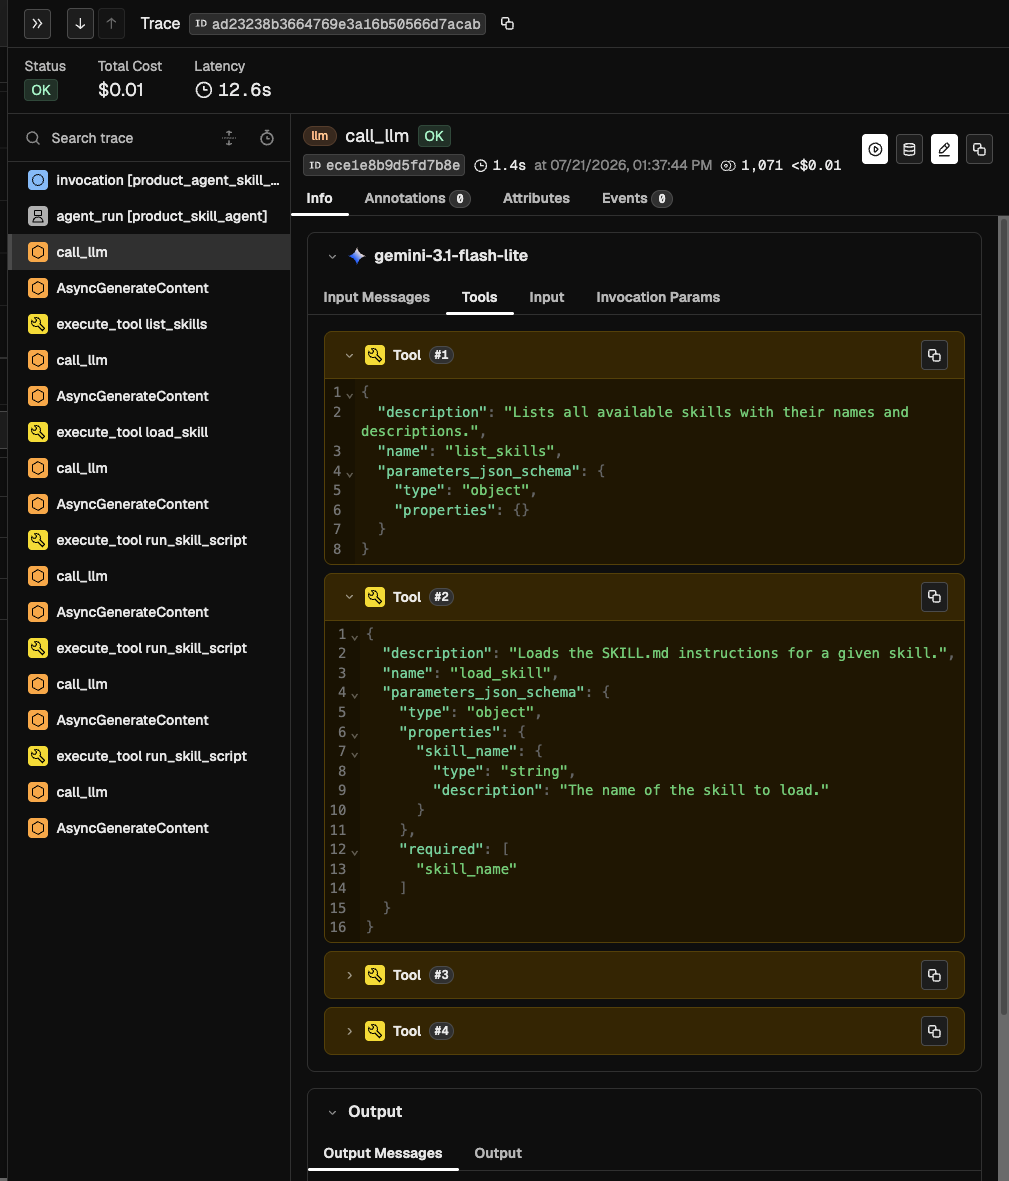

*`list_skills` and `load_skill` expose the capability on demand; the loaded `SKILL.md` then guides script execution.*

### Run turn 2 — retrieve details and compare

“Those two” depends on the session history. Search results contain enough information to shortlist products, while the detail operation adds seller, availability, brand, description, and specifications.

Before running the cell, predict how many detail lookups a grounded comparison requires.

In [10]:
SECOND_PROMPT = 'Compare those two using their full product details. Compare availability, seller, brand, and key specifications, then recommend one. Clearly identify any missing information.'

await skill_runner.run_debug(
    SECOND_PROMPT,
    session_id='product-agent-skill-session',
    verbose=True,
)

product_skill_agent > Here is a detailed comparison between the Hisense M7 Series and the TCL Q Series to help you decide.

### Comparison Table

| Feature | Hisense 55" M7 Series | TCL 55" Q Series (Q51K) |
| :--- | :--- | :--- |
| **Price** | $318.00 | $248.00 |
| **Rating** | 4.7 (80 reviews) | 4.4 (11,451 reviews) |
| **Display Tech** | Mini-LED | QLED |
| **Brightness** | Up to 1000 Nits | Not specified |
| **HDMI Inputs** | 4 | 3 |
| **Refresh Rate** | 60 Hz | 60 Hz |
| **Sound Tech** | Dolby Atmos + Subwoofer | Dolby Atmos + DTS Virtual:X |
| **Platform** | Google TV | Google TV |
| **Availability** | In Stock | In Stock |
| **Seller** | Walmart.com | Walmart.com |
| **Brand** | Hisense | TCL |

---

### Key Comparisons

*   **Display Technology:** The **Hisense M7** uses Mini-LED technology, which is generally superior for contrast and brightness compared to the standard LED-backlit QLED found in the **TCL Q Series**. The Hisense explicitly lists a peak brightness of 1000 nits,

[Event(model_version='gemini-3.1-flash-lite', content=Content(
   parts=[
     Part(
       text="""Here is a detailed comparison between the Hisense M7 Series and the TCL Q Series to help you decide.
 
 ### Comparison Table
 
 | Feature | Hisense 55" M7 Series | TCL 55" Q Series (Q51K) |
 | :--- | :--- | :--- |
 | **Price** | $318.00 | $248.00 |
 | **Rating** | 4.7 (80 reviews) | 4.4 (11,451 reviews) |
 | **Display Tech** | Mini-LED | QLED |
 | **Brightness** | Up to 1000 Nits | Not specified |
 | **HDMI Inputs** | 4 | 3 |
 | **Refresh Rate** | 60 Hz | 60 Hz |
 | **Sound Tech** | Dolby Atmos + Subwoofer | Dolby Atmos + DTS Virtual:X |
 | **Platform** | Google TV | Google TV |
 | **Availability** | In Stock | In Stock |
 | **Seller** | Walmart.com | Walmart.com |
 | **Brand** | Hisense | TCL |
 
 ---
 
 ### Key Comparisons
 
 *   **Display Technology:** The **Hisense M7** uses Mini-LED technology, which is generally superior for contrast and brightness compared to the standard LED-back

## Checks

### Flush the latest spans

Phoenix batches telemetry in the background. Flushing ensures the latest model and tool spans leave the notebook process before you open the trace explorer.

In [11]:
tracer_provider.force_flush()
print(f"Traces flushed to Phoenix project {PROJECT_NAME!r}.")

Traces flushed to Phoenix project 'product-notebook-saved-output-20260721'.


### What to notice in Phoenix

            Open your configured Phoenix project and inspect the two ADK turns. Model behavior is nondeterministic, so treat the expected path as a hypothesis and verify the actual spans.

            | Evidence | What it demonstrates |
            | --- | --- |
            | `list_skills` / `load_skill` spans | The model discovered the directory capability and loaded its full procedure. |
| `run_skill_script` spans | The model ran the bundled search and detail operations instead of receiving direct product function tools. |
            | Second model response | The final recommendation is synthesized from returned data rather than invented facts. |

            Ask three questions while reading the trace:

            1. Which fields came from search, and which required full product details?
            2. Where did the product IDs move from one operation to the next?
            3. Did the final answer clearly identify missing data?

### Compare the two implementations

| Ordinary function tools | Self-contained Agent Skill |
| --- | --- |
| Two Python functions are always registered on the agent. | One directory is discovered and loaded when relevant. |
| Tool docstrings describe each operation. | `SKILL.md` describes the complete multi-step procedure. |
| Trace names the product functions directly. | Trace shows skill loading and `run_skill_script`. |
| No general code executor is required. | The host explicitly chooses how trusted scripts execute. |

Neither architecture is universally better. Function tools are simpler for stable application APIs. A skill becomes valuable when the procedure, supporting files, and executable helpers should travel together as one reusable capability.

## Next Steps

1. Add a grounding rule to `SKILL.md` and rerun without changing the agent definition.
2. Ask for three products and inspect whether the agent retrieves all three detail records.
3. Break the script path deliberately and observe the skill error in Phoenix.
4. Discuss which executor boundary would be appropriate for an untrusted third-party skill.

Primary references:

- [Google ADK documentation](https://google.github.io/adk-docs/)
- [Agent Skills specification](https://agentskills.io/specification)
- [Phoenix tracing documentation](https://arize.com/docs/phoenix/tracing/how-to-tracing/setup-tracing)